In [1]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df1 = pd.read_csv("Data_files/games.csv",index_col = 0)
df1 = df1.reset_index(drop=True)

In [3]:
df1.shape

(1512, 13)

In [4]:
df1.head()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


In [5]:
df2 = pd.read_csv("Data_files/vgsales.csv",index_col = 0)

In [6]:
df2.shape

(16598, 10)

In [7]:
df2.head(5)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Duplicates

In [8]:
# FIND  DUPLICATES

print(df1.duplicated().sum()) 
print(df2.duplicated().sum())

382
1


In [9]:
# REMOVE DUPLICATES

df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()

## Null Values

In [10]:
# FIND  NULL VALUES

df1.isnull().sum()

Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [11]:
df2.isnull().sum()

Name              0
Platform          0
Year            270
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

## Handling Null values

In [12]:
#Replacing Rating null values with median

df1['Rating'] = df1['Rating'].fillna(df1["Rating"].median())  #Replacing Rating null values with median

In [13]:
df1["Release Date"] = pd.to_datetime(df1["Release Date"], errors="coerce")

In [14]:
df1[df1["Release Date"].isna()]

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
644,Deltarune,NaT,['tobyfox'],4.3,313,313,"['Adventure', 'Indie', 'Music', 'Puzzle', 'RPG']","UNDERTALE's parallel story, DELTARUNE. Meet ne...","['Spamton is so hot, I want to kiss him in the...",1.3K,83,468,617
649,Death Stranding 2,NaT,['Kojima Productions'],3.7,105,105,"['Adventure', 'Shooter']",NaN,[],3,0,209,644
1252,Elden Ring: Shadow of the Erdtree,NaT,"['FromSoftware', 'Bandai Namco Entertainment']",4.8,18,18,"['Adventure', 'RPG']",An expansion to Elden Ring setting players on ...,['I really loved that they integrated Family G...,1,0,39,146


In [15]:
## As we have only 3 missing values in release dates, I googled the dates and enter them individually

df1.loc[df1["Title"] == "Deltarune", "Release Date"] = pd.Timestamp("2025-06-05")
df1.loc[df1["Title"] == "Death Stranding 2", "Release Date"] = pd.Timestamp("2025-06-26")  # 26-06-2025
df1.loc[df1["Title"] == "Elden Ring: Shadow of the Erdtree", "Release Date"] = pd.Timestamp("2024-06-21")  #21-06-2024

In [16]:

df1[df1["Team"].isna() ]

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
1245,NEET Girl Date Night,2022-10-21,NaN,2.7,21,21,['Visual Novel'],Your friend sets you up on a date with his NEE...,"['this sucked. ""Omg she is literally me"" is no...",106,1,44,42


In [17]:
## As only one value is missing I googled and got the team name   ## Hitsuji

# df1['Team'] =  df1['Team'].fillna("Hitsuji")


## df2 null values

In [18]:
##  AS we already have publisher unknown with 203 rows we are changing null values to unknown in publisher

df2["Publisher"] = df2["Publisher"].fillna("Unknown")

In [19]:
df2["Year"] = df2["Year"].fillna(df2["Year"].median())
df2['Year'] = df2['Year'].astype(int)

## Data Types

In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1130 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              1130 non-null   object        
 1   Release Date       1130 non-null   datetime64[ns]
 2   Team               1129 non-null   object        
 3   Rating             1130 non-null   float64       
 4   Times Listed       1130 non-null   object        
 5   Number of Reviews  1130 non-null   object        
 6   Genres             1130 non-null   object        
 7   Summary            1129 non-null   object        
 8   Reviews            1130 non-null   object        
 9   Plays              1130 non-null   object        
 10  Playing            1130 non-null   object        
 11  Backlogs           1130 non-null   object        
 12  Wishlist           1130 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(11)
memory usage: 123.6+ KB

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16597 entries, 1 to 16600
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16597 non-null  object 
 1   Platform      16597 non-null  object 
 2   Year          16597 non-null  int64  
 3   Genre         16597 non-null  object 
 4   Publisher     16597 non-null  object 
 5   NA_Sales      16597 non-null  float64
 6   EU_Sales      16597 non-null  float64
 7   JP_Sales      16597 non-null  float64
 8   Other_Sales   16597 non-null  float64
 9   Global_Sales  16597 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 1.4+ MB


## Changing datatype in df1

In [22]:
# As K is determined as alphabet the columns are treated as object so change k to 1000
# Replace 'K' with 'e+03' and 'M' with 'e+06' in one go
# Use regex=True for the dictionary replacements to work as intended

df1.loc[:,'Times Listed'] = df1['Times Listed'].astype(str).replace({'K': 'e+03', 'M': 'e+06'}, regex=True)
df1.loc[:,'Number of Reviews'] = df1['Number of Reviews'].astype(str).replace({'K': 'e+03', 'M': 'e+06'}, regex=True)
df1.loc[:,'Plays'] = df1['Plays'].astype(str).replace({'K': 'e+03', 'M': 'e+06'}, regex=True)
df1.loc[:,'Playing'] = df1['Playing'].astype(str).replace({'K': 'e+03', 'M': 'e+06'}, regex=True)
df1.loc[:,'Backlogs'] = df1['Backlogs'].astype(str).replace({'K': 'e+03', 'M': 'e+06'}, regex=True)
df1.loc[:,'Wishlist'] = df1['Wishlist'].astype(str).replace({'K': 'e+03', 'M': 'e+06'}, regex=True)


In [23]:
df1['Times Listed'] = df1['Times Listed'].astype(float).astype(int)
df1['Number of Reviews'] = df1['Number of Reviews'].astype(float).astype(int)
df1['Plays'] = df1['Plays'].astype(float).astype(int)
df1['Playing'] = df1['Playing'].astype(float).astype(int)
df1['Backlogs'] = df1['Backlogs'].astype(float).astype(int)
df1['Wishlist'] = df1['Wishlist'].astype(float).astype(int)

## Descriptive Statistics for Data frames

In [24]:
df1.describe()

,Release Date,Rating,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
count,1130,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000
mean,2012-04-20 04:26:20.176990976,3.661504,616.907080,616.907080,5059.160177,196.723894,1187.567257,620.189381
min,1980-05-22 00:00:00,0.700000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,2006-11-19 00:00:00,3.400000,234.250000,234.250000,1500.000000,33.000000,385.000000,178.250000
50%,2013-11-14 12:00:00,3.700000,446.000000,446.000000,3300.000000,82.500000,772.500000,409.000000
75%,2019-06-18 06:00:00,4.100000,796.250000,796.250000,6900.000000,205.750000,1675.000000,778.000000
max,2025-06-26 00:00:00,4.800000,4300.000000,4300.000000,33000.000000,3800.000000,8300.000000,5400.000000
std,NaN,0.537467,574.182727,574.182727,5047.610513,346.527769,1162.493411,674.317430


In [25]:
df1.describe(include = object)

,Title,Team,Genres,Summary,Reviews
count,1130,1129,1130,1129,1130
unique,1099,764,255,1112,1117
top,Doom,['Capcom'],"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...",[]
freq,3,26,99,2,12


In [26]:
df2.describe()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16597.000000,16597.000000,16597.000000,16597.000000,16597.000000,16597.000000
mean,2006.416099,0.264683,0.146661,0.077785,0.048066,0.537472
std,5.781859,0.816705,0.505365,0.309300,0.188594,1.555070
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [27]:
df2.describe(include = object)

,Name,Platform,Genre,Publisher
count,16597,16597,16597,16597
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351


## Exploding Genre, Teams 

In [28]:
df1["Team"] = (df1["Team"].dropna().apply(ast.literal_eval))
df1 = df1.explode("Team")

In [29]:
## As only one value is missing I googled and got the team name   ## Hitsuji

df1['Team'] =  df1['Team'].fillna("Hitsuji")

In [30]:
import ast

df1["Genres"] = df1["Genres"].apply(ast.literal_eval)
df1 = (df1.explode("Genres").rename(columns={"Genres": "Genre"}))

## Generalizing Genres

In [31]:
GENRE_REPLACE = {"Brawler":"Action","Arcade": "Action","Sport":"Sports","Indie":"Misc","Music":"Misc","Quiz/Trivia":"Misc",
                "Pinball":"Misc","NaN":"Misc","RPG": "Role-Playing","Visual Novel":"Adventure","Point-and-Click":"Adventure",
                "Simulator":"Simulation","Turn Based Strategy":"Strategy","Card & Board Game":"Strategy","Tactical":"Strategy",
                "MOBA":"Strategy","Real Time Strategy":"Strategy"}

In [32]:
df1['Genre'] = df1['Genre'].replace(GENRE_REPLACE )

In [33]:
df1['Genre'] = df1['Genre'].fillna('Misc')

In [34]:
df1['Genre'].value_counts()  #'Sports',Simulation','Action'

Genre
Adventure       1482
Role-Playing     667
Shooter          494
Strategy         445
Platform         441
Misc             381
Action           304
Puzzle           232
Simulation       156
Fighting         120
Racing            65
Sports            35
Name: count, dtype: int64

### 1. What are the top-rated games by user reviews?

In [35]:
games_rev = df1.groupby('Title').agg(no_of_reviews = ('Number of Reviews','mean'))
top_game_Rev = games_rev.sort_values(by= 'no_of_reviews',ascending = False)
top_game_Rev.head(10)

,no_of_reviews
Title,
The Legend of Zelda: Breath of the Wild,4300.0
Elden Ring,3900.0
Undertale,3500.0
Bloodborne,3400.0
Hollow Knight,3000.0
Red Dead Redemption 2,2900.0
Super Mario Odyssey,2900.0
Hades,2900.0
Portal 2,2900.0


### 2. Which developers (Teams) have the highest average ratings?

In [36]:
team_rati = df1.groupby('Team').agg(avg_rating = ('Rating','mean'))
top_team_rati = team_rati.sort_values(by= 'avg_rating',ascending = False)
top_team_rati.head(10)


,avg_rating
Team,
ZA/UM,4.600000
Inlusio Interactive,4.600000
Kitfox Games,4.600000
Konami Digital Entertainment,4.600000
Bay 12 Games,4.600000
Mobius Digital,4.544444
EA,4.500000
CD Projekt,4.500000
Tour De Pizza,4.500000


### 3.	What are the most common genres in the dataset?

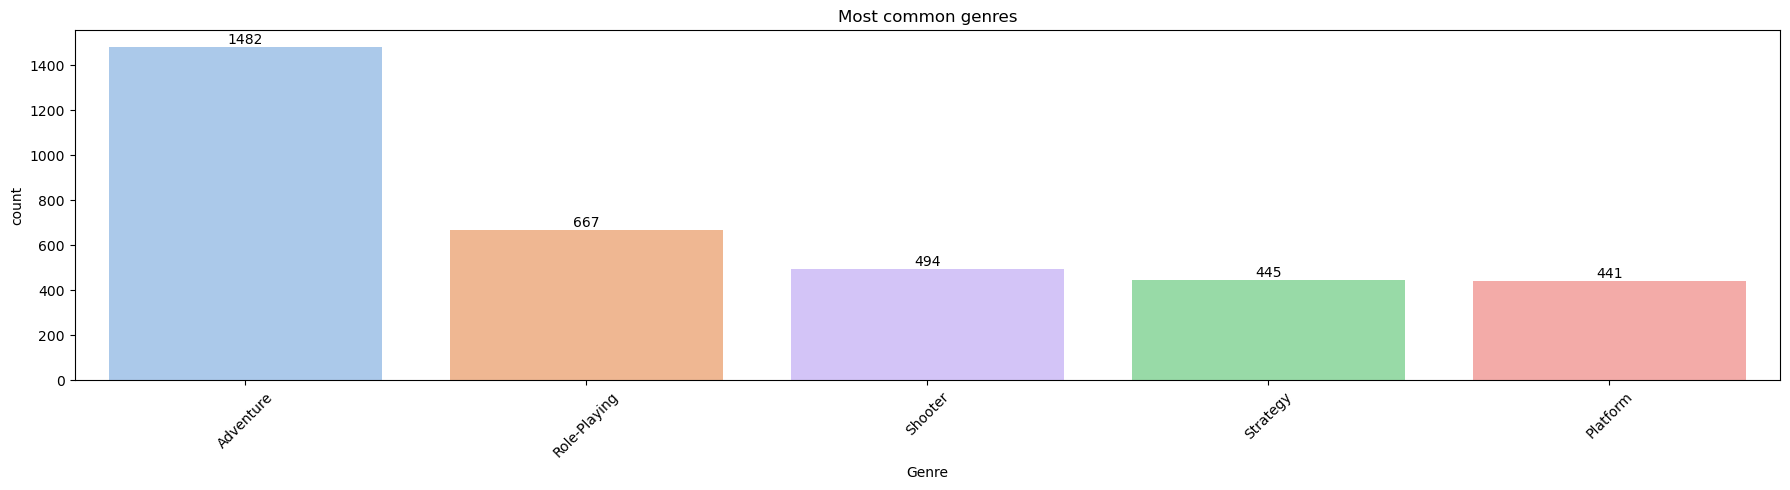

In [37]:
top5 = df1['Genre'].value_counts().head(5)

plt.figure(figsize=(18,5))

ax = sns.countplot(data=df1[df1['Genre'].isin(top5.index)],x='Genre',order=top5.index, hue='Genre',palette='pastel',legend=False)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Most common genres')
plt.tight_layout()

### 4. Which games have the highest backlog compared to wishlist?

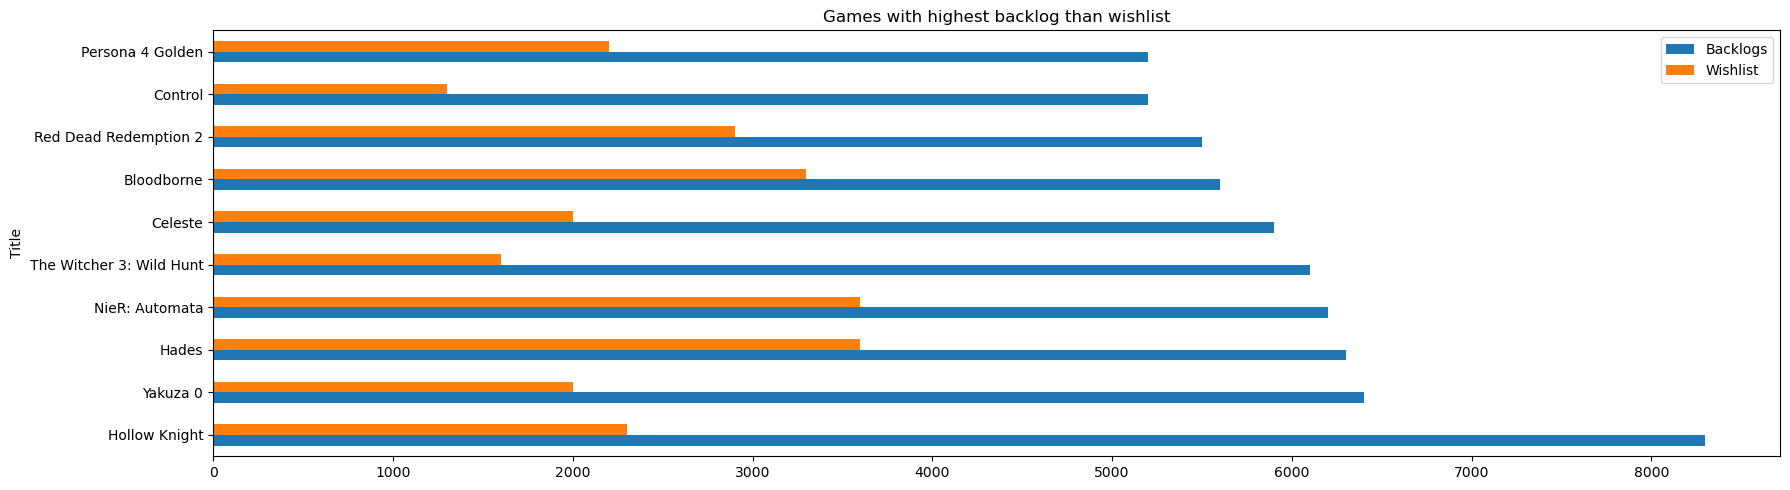

In [38]:
top_backlog_games = df1.sort_values(by='Backlogs', ascending=False)
top_backlog_games_unique = top_backlog_games.drop_duplicates(subset='Title', keep='first')
z = top_backlog_games_unique[['Title', 'Backlogs', 'Wishlist']].head(10).reset_index(drop = True)
z.plot(x='Title',kind='barh',stacked=False,title='Games with highest backlog than wishlist',figsize = (18,5))
plt.tight_layout()

## 5.What is the game release trend across years?




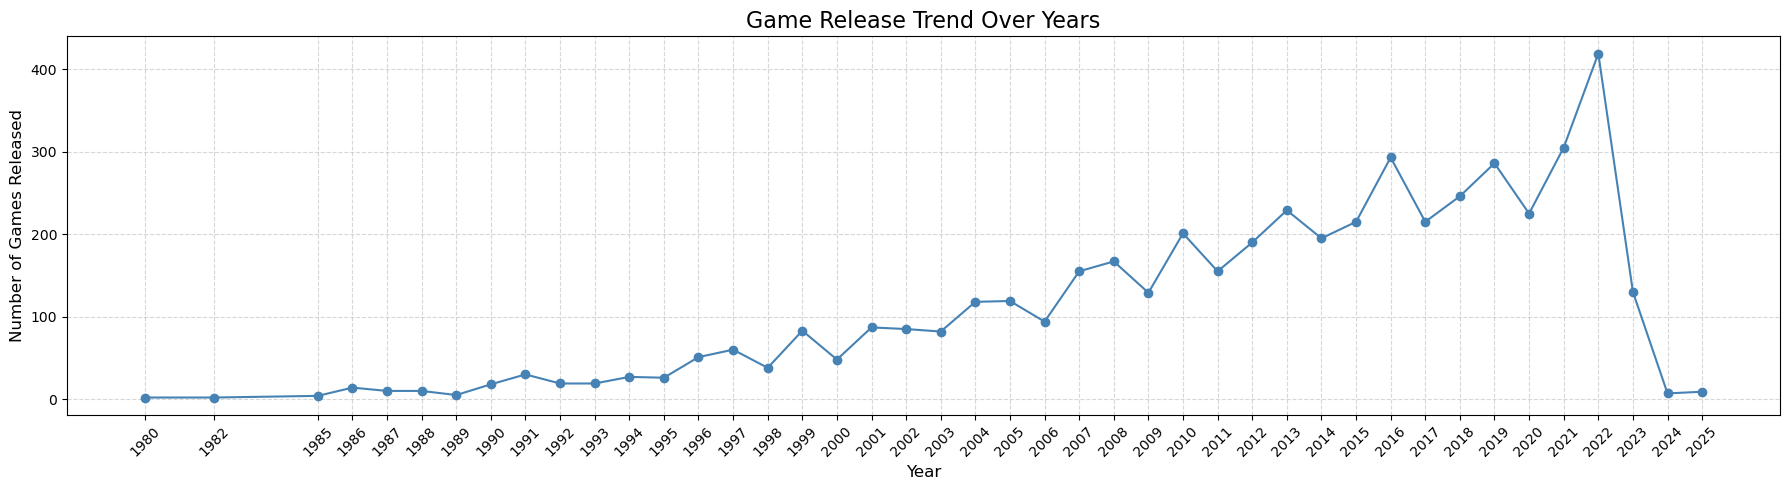

In [39]:
# Count number of games released each year
release_trend = df1['Release Date'].dt.year.value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.plot(release_trend.index, release_trend.values, marker='o', linestyle='-', color='steelblue')
plt.title('Game Release Trend Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Games Released', fontsize=12)
plt.xticks(release_trend.index,rotation = 45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 6. What is the distribution of user ratings?


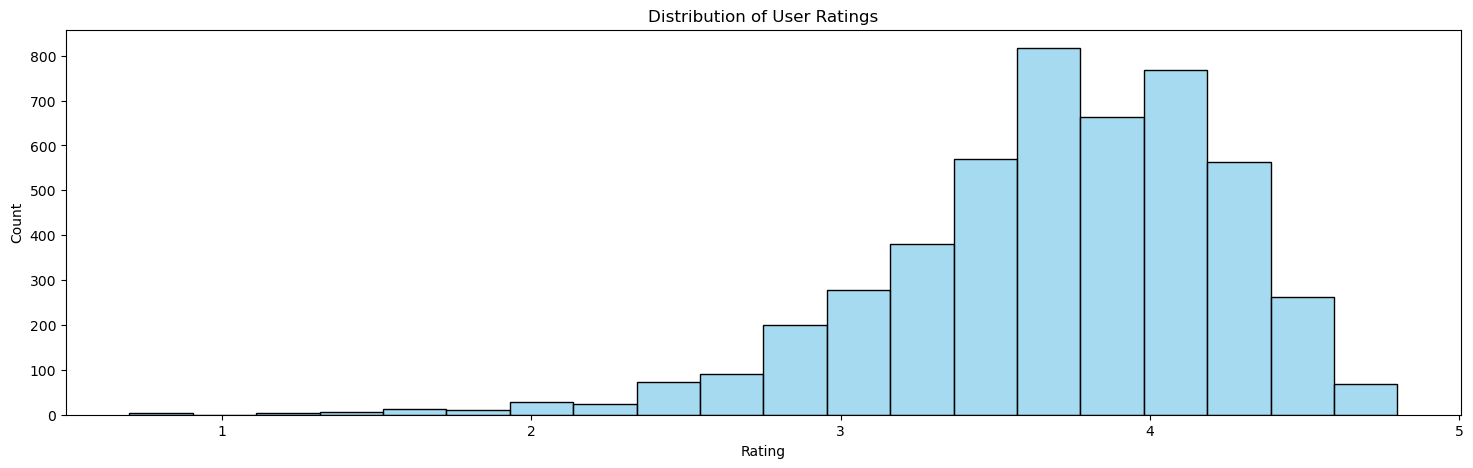

In [40]:
plt.figure(figsize=(18,5))
sns.histplot(df1['Rating'], bins=20, kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


### 7.What are the top 10 most wishlisted games?

In [41]:
top_wishlist = df1.sort_values(by ='Wishlist', ascending = False)
top_wishlist_unique = top_wishlist.drop_duplicates(subset='Title', keep='first')
top_wishlist_unique[['Title','Wishlist']].head(10).reset_index(drop = True)

,Title,Wishlist
0,The Legend of Zelda: Tears of the Kingdom,5400
1,Elden Ring,4800
2,Omori,3800
3,NieR Replicant ver.1.22474487139...,3700
4,NieR: Automata,3600
5,Hades,3600
6,Stray,3400
7,Sekiro: Shadows Die Twice,3400
8,God of War Ragnarök,3300
9,Bloodborne,3300


### 8. What’s the average number of plays per genre?

In [42]:
avg_plays = df1.groupby('Genre')['Plays'].mean().round(0)

top_plays_genre = avg_plays.sort_values(ascending=False)
pd.DataFrame(top_plays_genre)

,Plays
Genre,
Shooter,6380.0
Racing,5962.0
Platform,5764.0
Role-Playing,5255.0
Adventure,5193.0
Action,4858.0
Simulation,4822.0
Strategy,4654.0
Puzzle,4343.0


### 9.Which developer studios are the most productive and impactful?

In [43]:
avg_playing = df1.groupby('Team')['Playing'].mean().round(0)

top_playing_team = avg_playing.sort_values(ascending=False)
print(top_playing_team.head(10))

Team
HoYoverse                              2700.0
miHoYo                                 2700.0
ConcernedApe                           2000.0
Chucklefish Games                      2000.0
Team Cherry                            1348.0
Nintendo EPD Production Group No. 3    1253.0
Maddy Makes Games                      1200.0
GOA Games Services Ltd.                1200.0
Mojang Studios                         1154.0
Capcom Development Division 2          1100.0
Name: Playing, dtype: float64


## 10 Which region generates the most game sales?

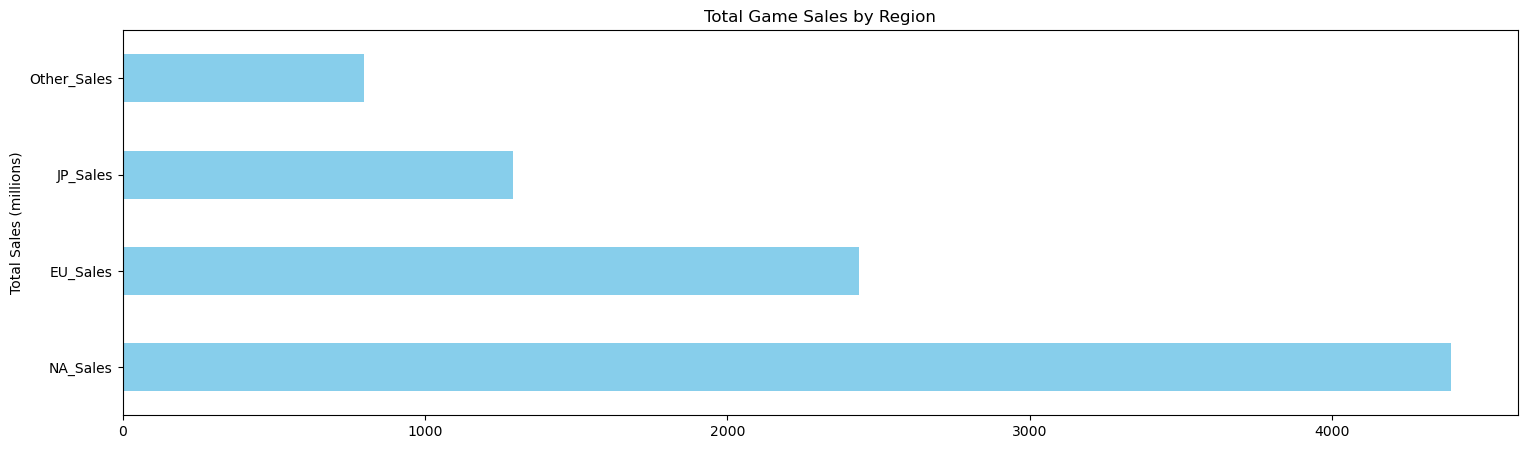

In [44]:
region_sales = df2[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()

region_sales.plot(kind="barh", color="skyblue", figsize=(18,5))
plt.ylabel("Total Sales (millions)")
plt.title("Total Game Sales by Region")
plt.show()


## 11. What are the best-selling platforms?

In [45]:
Plat_sales = df2.groupby('Platform').agg(Total_sales = ('Global_Sales','sum'))

top_platform_sales = Plat_sales.sort_values(by = 'Total_sales',ascending=False)
top_platform_sales.head(5)

,Total_sales
Platform,
PS2,1255.64
X360,979.96
PS3,957.84
Wii,926.69
DS,822.49


## 12. What’s the trend of game releases and sales over years?

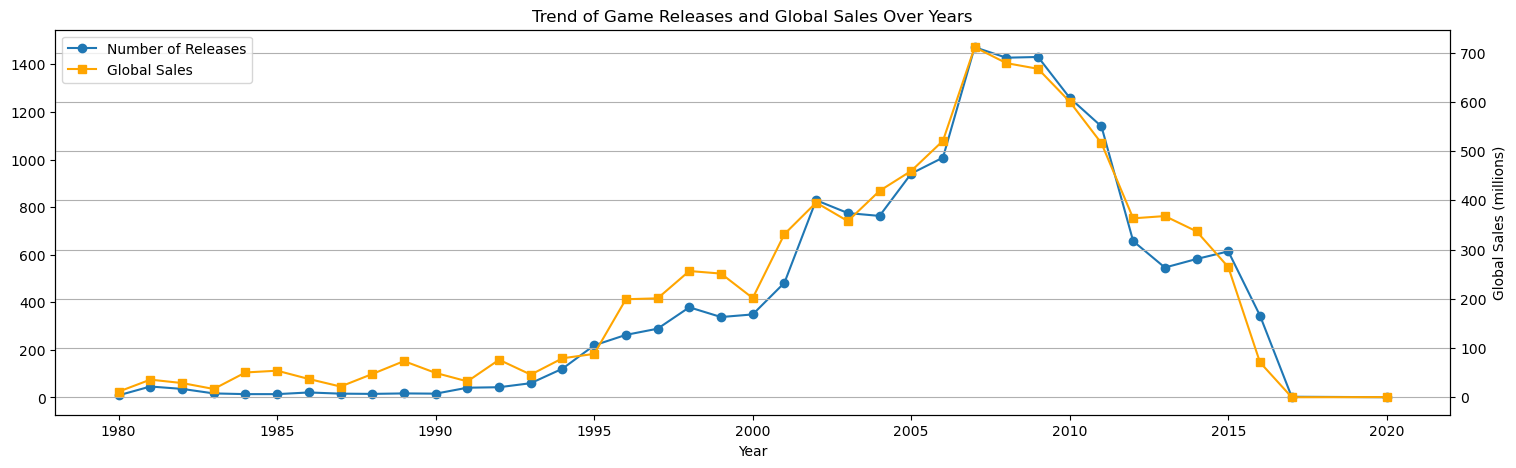

In [46]:
# Number of releases per year
releases_per_year = df2.groupby('Year')['Name'].count()

# Total sales per year
sales_per_year = df2.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(18,5))

# Plot number of releases
line1 = releases_per_year.plot(kind='line', marker='o', label='Number of Releases')

# Plot total sales on secondary axis
ax2 = plt.twinx()
line2 = sales_per_year.plot(kind='line', marker='s', color='orange', label='Global Sales', ax=ax2)

# Combine legends from both axes, avoid duplicates
lines, labels = line1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Combine and remove duplicates
all_lines = lines + [l for l in lines2 if l not in lines]
all_labels = labels + [lab for lab in labels2 if lab not in labels]

plt.legend(all_lines, all_labels, loc='upper left')

plt.title('Trend of Game Releases and Global Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
ax2.set_ylabel('Global Sales (millions)')

plt.grid(True)
plt.show()



## 13. Who are the top publishers by sales?

In [47]:
df2.groupby('Publisher').agg(Total_sales = ('Global_Sales',"sum")).sort_values(by = 'Total_sales',ascending=False).head(10)

,Total_sales
Publisher,
Nintendo,1786.54
Electronic Arts,1110.32
Activision,727.46
Sony Computer Entertainment,607.50
Ubisoft,474.72
Take-Two Interactive,399.54
THQ,340.77
Konami Digital Entertainment,283.64
Sega,272.99


## 14 .Which games are the top 10 best-sellers globally?

In [48]:
df2.groupby('Name').agg(sales = ('Global_Sales','sum')).sort_values(by = 'sales',ascending=False).head(10)

,sales
Name,
Wii Sports,82.74
Grand Theft Auto V,55.92
Super Mario Bros.,45.31
Tetris,35.84
Mario Kart Wii,35.82
Wii Sports Resort,33.00
Pokemon Red/Pokemon Blue,31.37
Call of Duty: Black Ops,31.03
Call of Duty: Modern Warfare 3,30.83


## 15. How do regional sales compare for specific platforms?

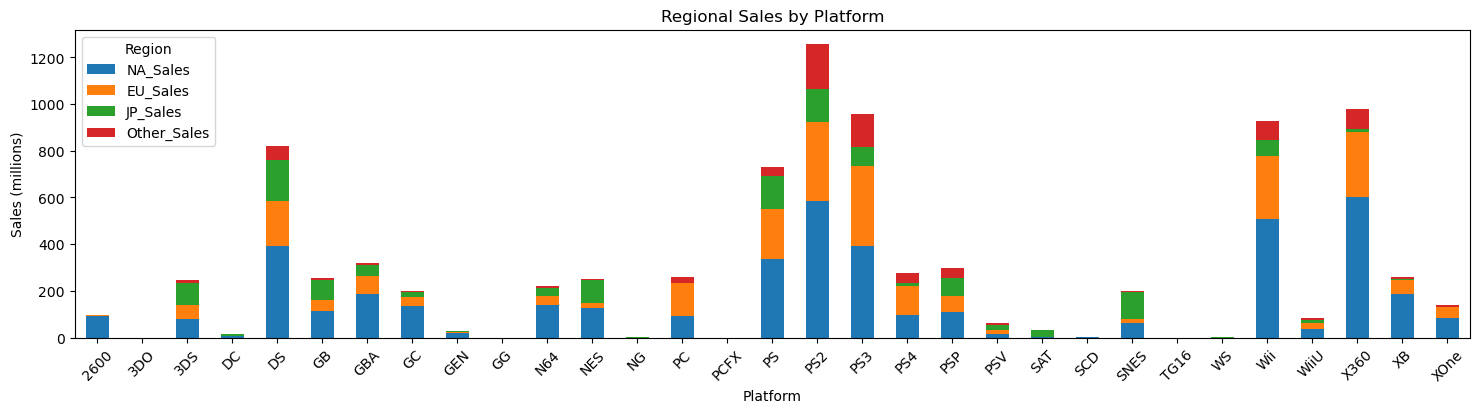

In [49]:
# Sum regional sales per platform
platform_sales = df2.groupby("Platform")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()


platform_sales.plot(kind="bar", stacked=True, figsize=(18,4))

plt.ylabel("Sales (millions)")
plt.title("Regional Sales by Platform")
plt.legend(title="Region")
plt.xticks(rotation=45)
plt.show()

## 16. How has the market evolved by platform over time?

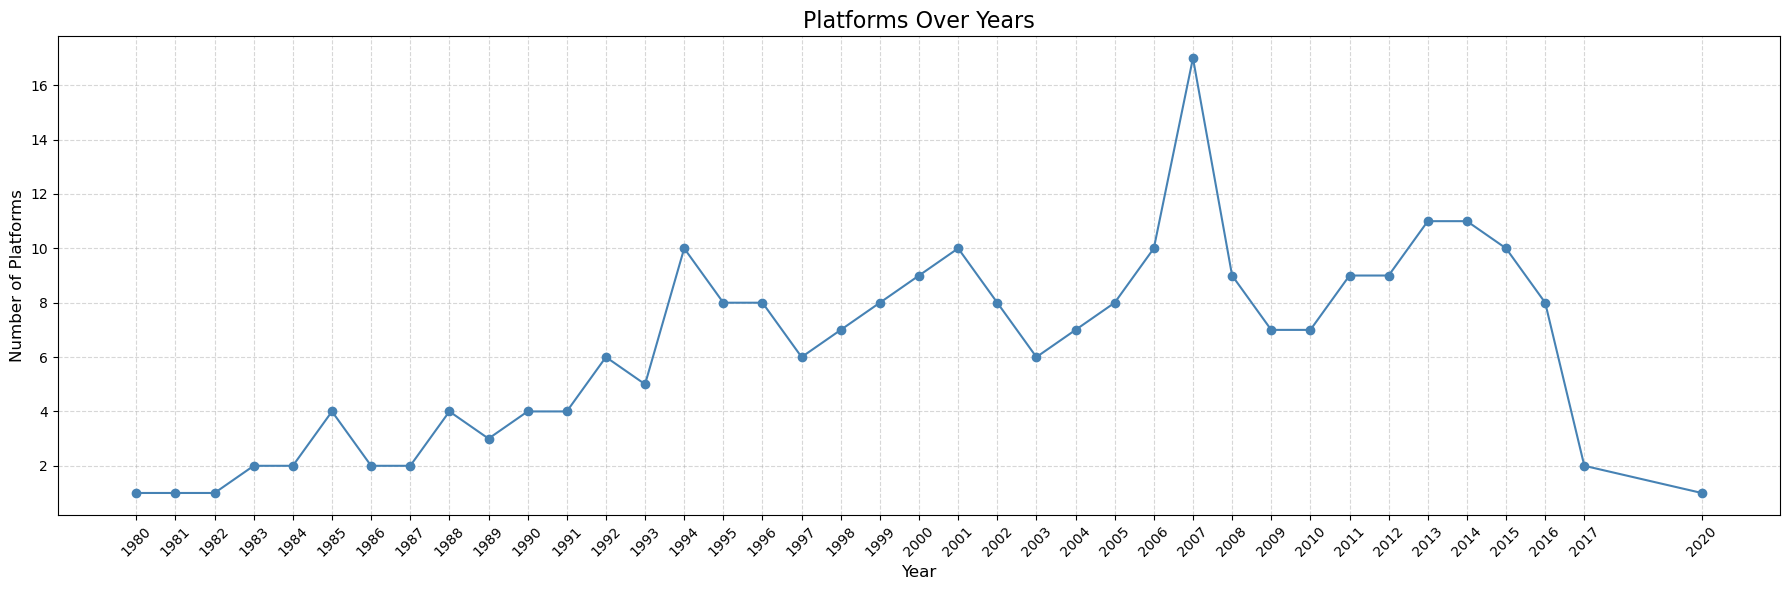

In [50]:
# Count number of games released each year
release_trend = df2.groupby('Year')['Platform'].nunique()

plt.figure(figsize=(18,6))
plt.plot(release_trend.index, release_trend.values, marker='o', linestyle='-', color='steelblue')
plt.title('Platforms Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Platforms', fontsize=12)
plt.xticks(release_trend.index,rotation = 45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



## 17. What are the regional genre preferences?

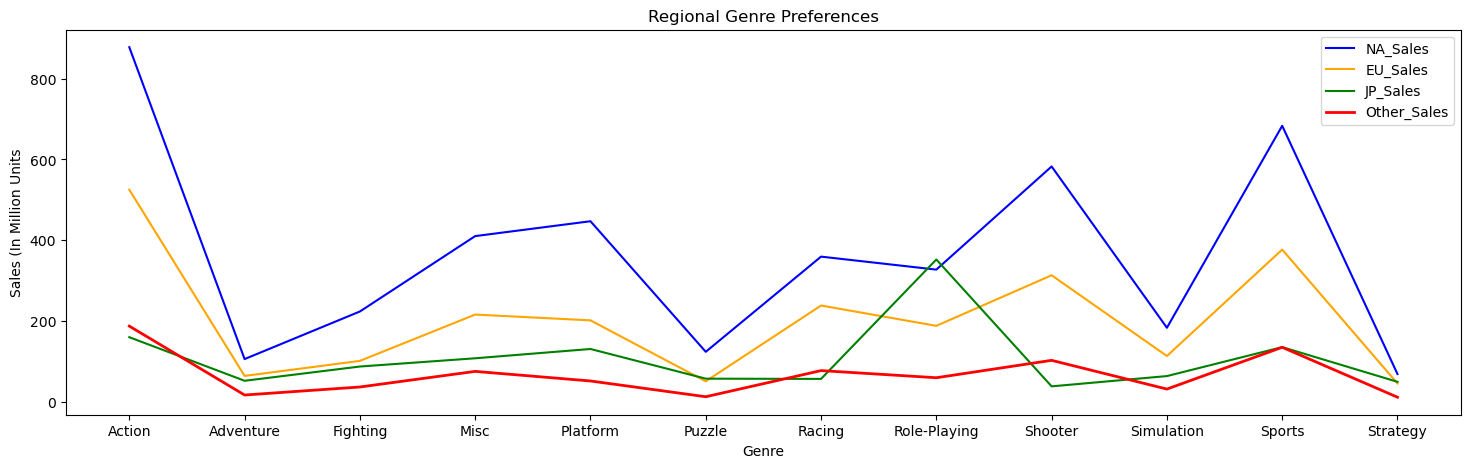

In [51]:
plt.figure(figsize=(18,5))
y1 = df2.groupby('Genre')['NA_Sales'].sum()
y2 = df2.groupby('Genre')['EU_Sales'].sum()
y3 = df2.groupby('Genre')['JP_Sales'].sum()
y4 = df2.groupby('Genre')['Other_Sales'].sum()
# Plot each line
plt.plot(y1.index, y1.values, label='NA_Sales', color='Blue') # Add markers for clarity
plt.plot(y2.index, y2.values, label='EU_Sales', color='Orange') # Use different line styles
plt.plot(y3.index, y3.values, label='JP_Sales', color='green') # Specify color
plt.plot(y4.index, y4.values, label='Other_Sales', color='red', linewidth=2) # Specify color and width

# Add labels, title, and legend for readability
plt.xlabel('Genre')
plt.ylabel('Sales (In Million Units')
plt.title('Regional Genre Preferences')
plt.legend() # Shows the legend with the labels specified in each plot call

# Display the chart
plt.show()


## 18. What’s the yearly sales change per region?

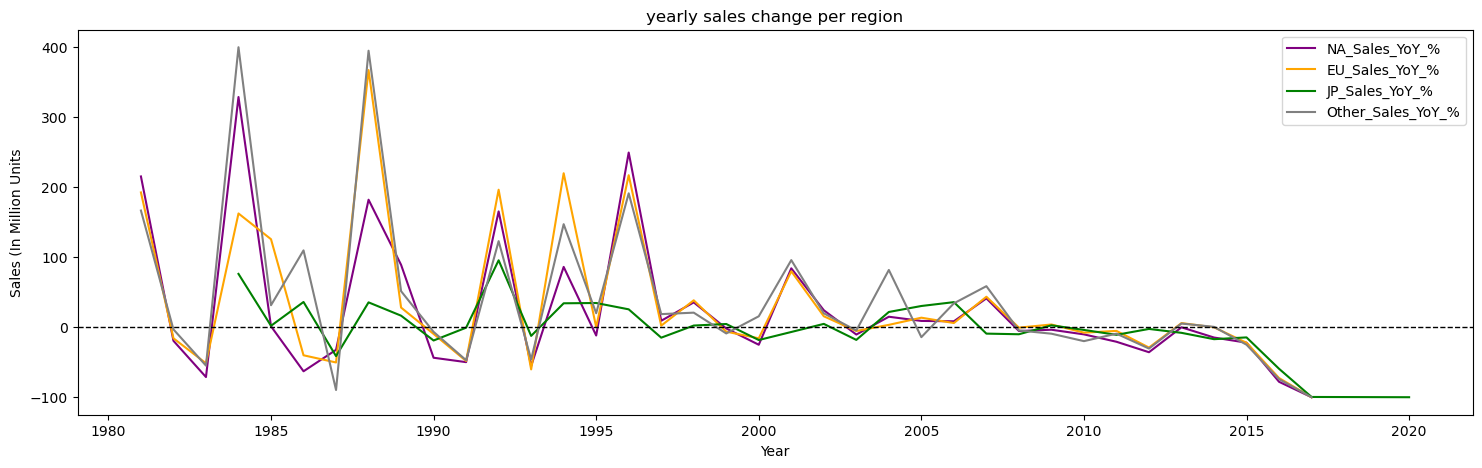

In [52]:
df_yearly = df2.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum().reset_index()


# year_sales = df2[['Year','NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sort_values('Year')
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

for region in regions:
    df_yearly[region + '_YoY_%'] = df_yearly[region].pct_change() * 100

plt.figure(figsize=(18,5))

# Plot each line
plt.plot(df_yearly['Year'], df_yearly['NA_Sales_YoY_%'], label='NA_Sales_YoY_%', color='Purple') 
plt.plot(df_yearly['Year'], df_yearly['EU_Sales_YoY_%'], label='EU_Sales_YoY_%', color='Orange') 
plt.plot(df_yearly['Year'], df_yearly['JP_Sales_YoY_%'], label='JP_Sales_YoY_%', color='Green') 
plt.plot(df_yearly['Year'], df_yearly['Other_Sales_YoY_%'], label='Other_Sales_YoY_%', color='Grey') 
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)



# Add labels, title, and legend for readability
plt.xlabel('Year')
plt.ylabel('Sales (In Million Units')
plt.title('yearly sales change per region')
plt.legend() # Shows the legend with the labels specified in each plot call

# Display the chart
plt.show()

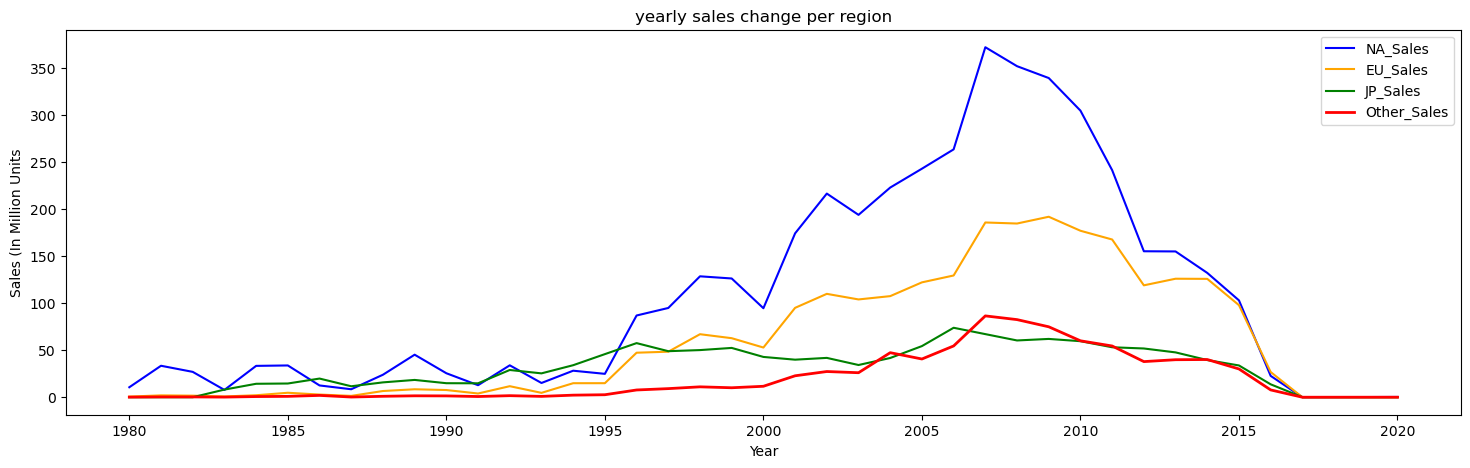

In [53]:

plt.figure(figsize=(18,5))
y1 = df2.groupby('Year')['NA_Sales'].sum()
y2 = df2.groupby('Year')['EU_Sales'].sum()
y3 = df2.groupby('Year')['JP_Sales'].sum()
y4 = df2.groupby('Year')['Other_Sales'].sum()
# Plot each line
plt.plot(y1.index, y1.values, label='NA_Sales', color='Blue') # Add markers for clarity
plt.plot(y2.index, y2.values, label='EU_Sales', color='Orange') # Use different line styles
plt.plot(y3.index, y3.values, label='JP_Sales', color='green') # Specify color
plt.plot(y4.index, y4.values, label='Other_Sales', color='red', linewidth=2) # Specify color and width

# Add labels, title, and legend for readability
plt.xlabel('Year')
plt.ylabel('Sales (In Million Units')
plt.title('yearly sales change per region')
plt.legend() # Shows the legend with the labels specified in each plot call

# Display the chart
plt.show()


## 19. What is the average sales per publisher?

In [54]:
publ_sales = df2.groupby("Publisher").agg(Avg_sales = ('Global_Sales','mean'))
publ_sales.sort_values(by = 'Avg_sales',ascending = False).head(10)

,Avg_sales
Publisher,
Palcom,4.170000
Red Orb,2.620000
Nintendo,2.544929
Arena Entertainment,2.360000
UEP Systems,2.250000
RedOctane,2.170000
Valve,1.740000
Hello Games,1.600000
Sony Computer Entertainment Europe,1.592667


## 20. What are the top 5 best-selling games per platform?

In [55]:
# sort by platform + sales descending
df_sorted = df2.sort_values(by=["Platform", "Global_Sales"], ascending= [True,False])

# take top 5 games per platform
top_5_per_platform = (df_sorted.groupby("Platform").head(5)[["Platform", "Name", "Global_Sales"]].reset_index(drop=True))
top_5_per_platform

,Platform,Name,Global_Sales
0,2600,Pac-Man,7.81
1,2600,Pitfall!,4.50
2,2600,Asteroids,4.31
3,2600,Missile Command,2.76
4,2600,Space Invaders,2.53
...,...,...,...
137,XOne,Call of Duty: Black Ops 3,7.30
138,XOne,Call of Duty: Advanced Warfare,5.13
139,XOne,Grand Theft Auto V,5.08
140,XOne,Halo 5: Guardians,4.26


## Joining two datasets

In [56]:
df3 = pd.merge(df1,df2, left_on = "Title", right_on = "Name", how = "inner")

In [57]:
df3[df3['Publisher'] == 'Unknown']

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genre_x,Summary,Reviews,Plays,...,Name,Platform,Year,Genre_y,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
167,Persona 5,2016-09-15,Atlus,4.1,1800,1800,Adventure,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Unknown,0.0,0.00,0.10,0.00,0.10
169,Persona 5,2016-09-15,Atlus,4.1,1800,1800,Role-Playing,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Unknown,0.0,0.00,0.10,0.00,0.10
171,Persona 5,2016-09-15,Atlus,4.1,1800,1800,Strategy,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Unknown,0.0,0.00,0.10,0.00,0.10
173,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Adventure,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Unknown,0.0,0.00,0.10,0.00,0.10
175,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Role-Playing,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Unknown,0.0,0.00,0.10,0.00,0.10
177,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Strategy,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Unknown,0.0,0.00,0.10,0.00,0.10
270,Terraria,2011-05-16,Re-Logic,4.0,1300,1300,Adventure,"Dig, Fight, Explore, Build: The very world is ...",['It’s 2d Minecraft and I wish it had that ext...,18000,...,Terraria,PC,2011,Action,Unknown,0.0,0.13,0.00,0.02,0.15
278,Terraria,2011-05-16,Re-Logic,4.0,1300,1300,Misc,"Dig, Fight, Explore, Build: The very world is ...",['It’s 2d Minecraft and I wish it had that ext...,18000,...,Terraria,PC,2011,Action,Unknown,0.0,0.13,0.00,0.02,0.15
286,Terraria,2011-05-16,Re-Logic,4.0,1300,1300,Platform,"Dig, Fight, Explore, Build: The very world is ...",['It’s 2d Minecraft and I wish it had that ext...,18000,...,Terraria,PC,2011,Action,Unknown,0.0,0.13,0.00,0.02,0.15
294,Terraria,2011-05-16,Re-Logic,4.0,1300,1300,Role-Playing,"Dig, Fight, Explore, Build: The very world is ...",['It’s 2d Minecraft and I wish it had that ext...,18000,...,Terraria,PC,2011,Action,Unknown,0.0,0.13,0.00,0.02,0.15


In [58]:
# Replace 'unknown' (case-insensitive) in publisher with the value from team column

mask = df3['Publisher'].fillna('Unknown').str.lower() == 'unknown'
df3.loc[mask, 'Publisher'] = df3.loc[mask, 'Team']

In [59]:
df3[df3['Team'].isin(["NIS America","Atlus USA","Sonic Team","Headup Games"])]

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genre_x,Summary,Reviews,Plays,...,Name,Platform,Year,Genre_y,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
172,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Adventure,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS4,2016,Role-Playing,Atlus,0.00,0.00,0.34,0.00,0.34
173,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Adventure,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Atlus USA,0.00,0.00,0.10,0.00,0.10
174,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Role-Playing,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS4,2016,Role-Playing,Atlus,0.00,0.00,0.34,0.00,0.34
175,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Role-Playing,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS3,2016,Role-Playing,Atlus USA,0.00,0.00,0.10,0.00,0.10
176,Persona 5,2016-09-15,Atlus USA,4.1,1800,1800,Strategy,"Persona 5, a turn-based JRPG with visual novel...",['Just play Royal instead bro why u reading th...,16000,...,Persona 5,PS4,2016,Role-Playing,Atlus,0.00,0.00,0.34,0.00,0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3228,Puyo Puyo Tetris,2014-02-06,Sonic Team,3.8,233,233,Strategy,"""Two puzzle game juggernauts collide as Tetris...",['10/10 the itch to the scratch for Tetris and...,3100,...,Puyo Puyo Tetris,PSV,2014,Puzzle,Sega,0.00,0.00,0.05,0.00,0.05
3229,Puyo Puyo Tetris,2014-02-06,Sonic Team,3.8,233,233,Strategy,"""Two puzzle game juggernauts collide as Tetris...",['10/10 the itch to the scratch for Tetris and...,3100,...,Puyo Puyo Tetris,PS3,2014,Puzzle,Sega,0.00,0.00,0.04,0.00,0.04
3230,Puyo Puyo Tetris,2014-02-06,Sonic Team,3.8,233,233,Strategy,"""Two puzzle game juggernauts collide as Tetris...",['10/10 the itch to the scratch for Tetris and...,3100,...,Puyo Puyo Tetris,WiiU,2014,Puzzle,Sega,0.00,0.00,0.02,0.00,0.02
3366,Sonic Rush Adventure,2007-09-14,Sonic Team,3.5,278,278,Platform,Sonic returns to the DS with all the classic 2...,['La La... La La... La La...\n ...,1900,...,Sonic Rush Adventure,DS,2007,Platform,Sega,0.54,0.49,0.01,0.12,1.17


In [60]:
## DROPPING ROWS WHERE TEAM = NIS America,Atlus USA,Sonic Team,Headup Games
df3 = df3[~df3["Team"].isin(["NIS America","Atlus USA","Sonic Team","Headup Games"])]

## Combining Genres of 2 datasets

In [61]:
def combine_genres(genre, genrex):
    if genrex.lower() in genre.lower():
        return genre
    return f"{genre}, {genrex}"

df3.loc[:,"genre_combined"] = df3.apply(lambda row: combine_genres(row["Genre_x"], row["Genre_y"]),axis=1)

## Create new dataset with required columns

In [62]:
df4 = df3[['Title', 'Release Date','genre_combined', 'Rating', 'Times Listed',
       'Number of Reviews', 'Plays','Playing', 'Backlogs', 'Wishlist', 'Platform',
       'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales','Other_Sales', 'Global_Sales' ]]

In [63]:
df4.shape

(3704, 17)

In [64]:
## Splitting Genre_combined column

df4.loc[:,"genre_combined"] = df4["genre_combined"].str.split(',')
df4 = df4.explode("genre_combined")

In [65]:
## Stripping spaces after splitting

df4.loc[:,'genre_combined'] = df4['genre_combined'].str.strip()

In [66]:
df4.duplicated().sum()

np.int64(3810)

In [67]:
## Remove duplicates

df4 = df4.drop_duplicates()

In [68]:
df4.shape

(2228, 17)

## 21. Which game genres generate the most global sales?

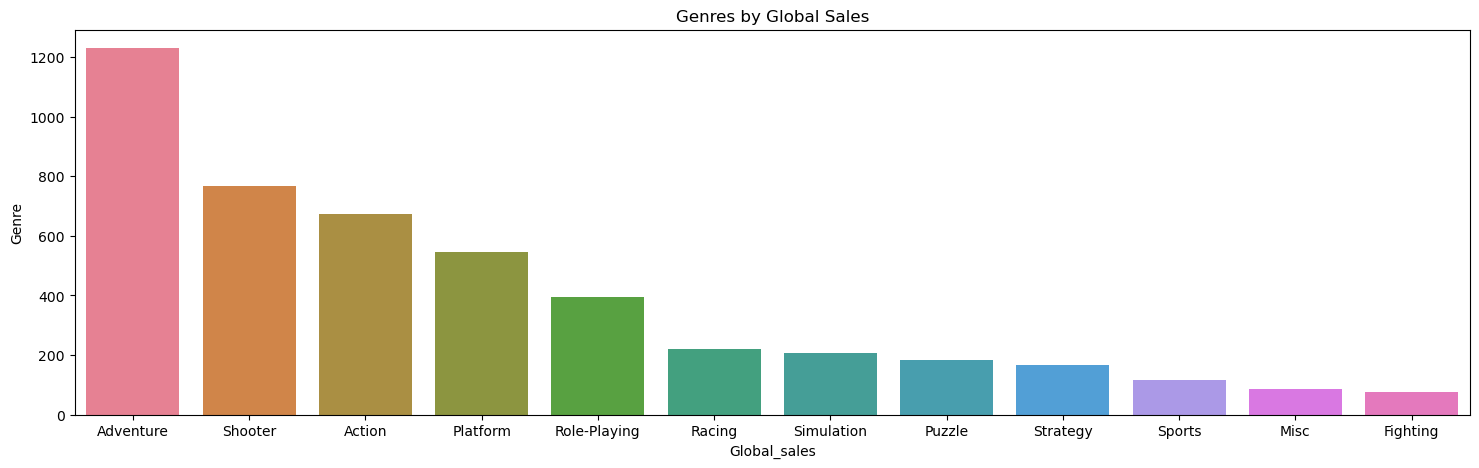

In [69]:
A = df4.groupby("genre_combined").agg(Total_sales = ("Global_Sales","sum")).sort_values(by = "Total_sales",ascending = False)
plt.figure(figsize = (18,5))
sns.barplot(data = A,x = "genre_combined",y = "Total_sales",hue = "genre_combined")
plt.title('Genres by Global Sales')
plt.xlabel('Global_sales')
plt.ylabel('Genre')
plt.show()


## 22. How does user rating affect global sales?

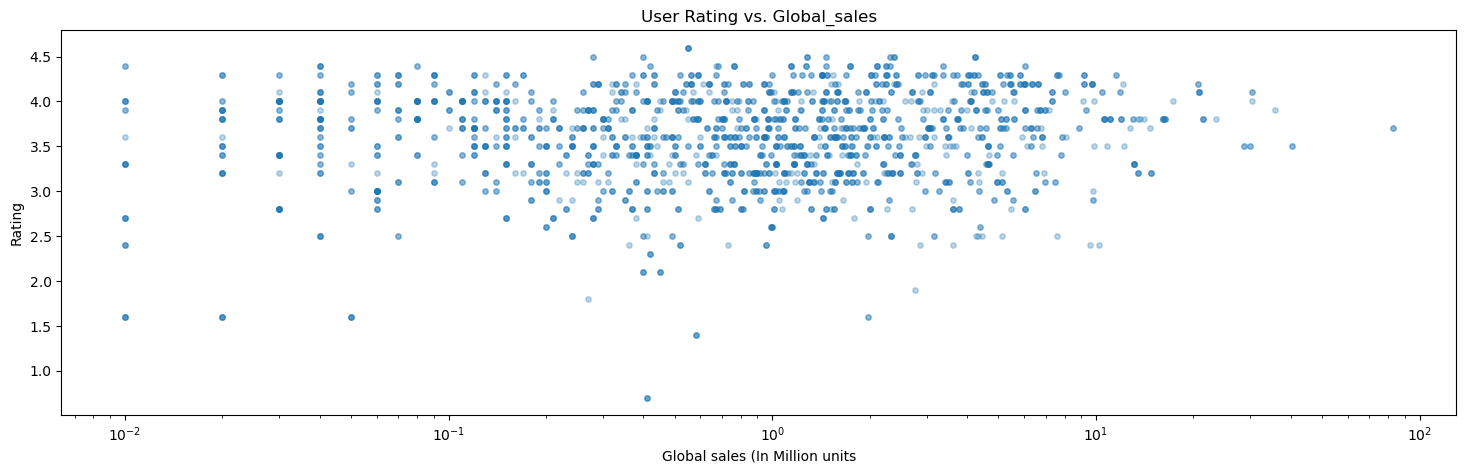

In [70]:
plt.figure(figsize = (18,5))

plt.scatter(x = df4['Global_Sales'], y = df4['Rating'], alpha=0.3, s=15)
# # sns.regplot(data = df4, x = 'Global_Sales', y = 'Rating')
plt.xscale('log')
plt.title('User Rating vs. Global_sales')
plt.ylabel('Rating')
plt.xlabel('Global sales (In Million units')
plt.show()


## 23. Which platforms have the most games with high ratings (e.g., above 4)?

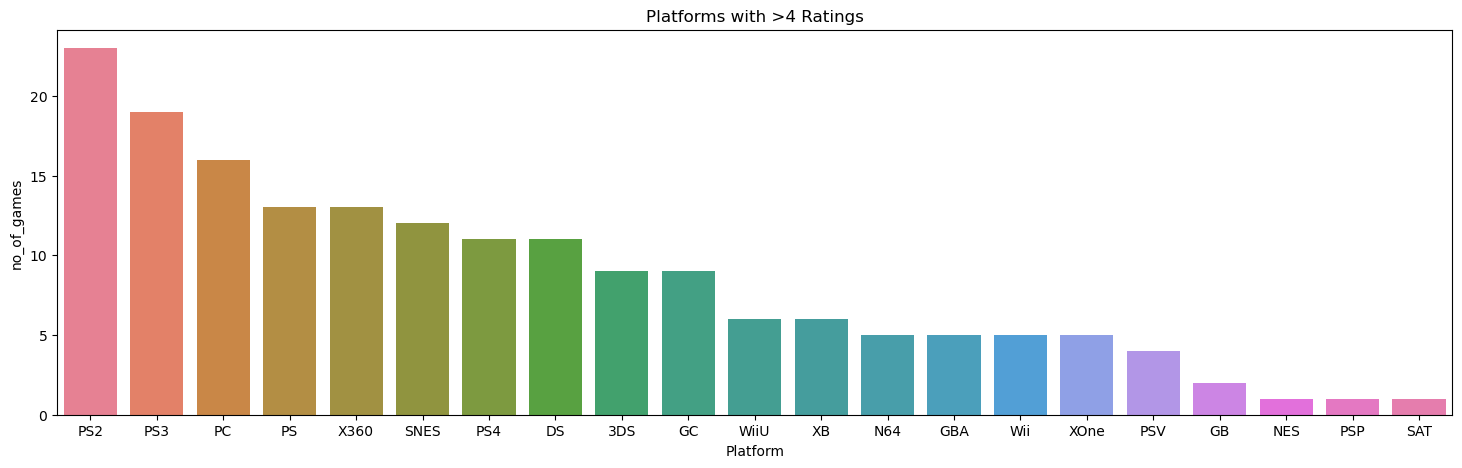

In [71]:
x = df4.loc[(df4["Rating"] > 4,['Title','Rating','Platform'])].sort_values(by = "Rating",ascending = False)
y = x.drop_duplicates()
J = y.groupby("Platform").agg(no_of_games = ('Title','count')).sort_values(by = "no_of_games",ascending = False)
plt.figure(figsize = (18,5))
sns.barplot(data = J,x = "Platform",y = "no_of_games",hue = "Platform")
plt.title('Platforms with >4 Ratings')
plt.show()

## 24. What’s the trend of releases and sales over time?

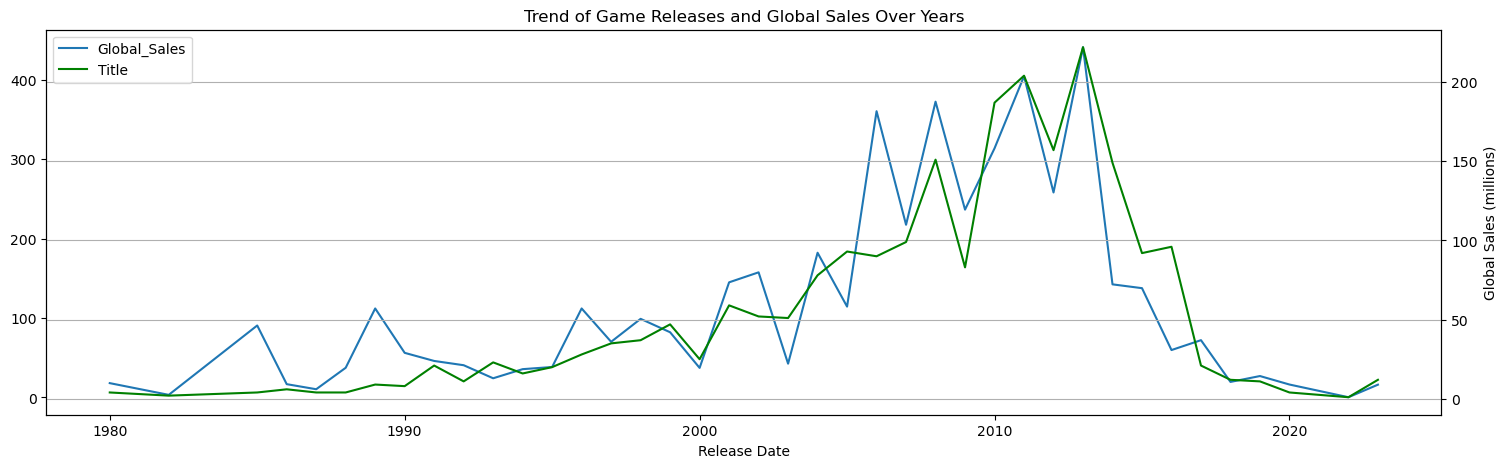

In [72]:
plt.figure(figsize=(18,5))
y1 = df4.groupby(df4["Release Date"].dt.year)['Global_Sales'].sum()
y2 = df4.groupby(df4["Release Date"].dt.year)['Title'].count()

# Plot each line

line1 =y1.plot(kind = 'line')
ax2= plt.twinx()
line2 = y2.plot(kind = 'line',color = 'green')

# Combine legends from both axes, avoid duplicates
lines, labels = line1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Combine and remove duplicates
all_lines = lines + [l for l in lines2 if l not in lines]
all_labels = labels + [lab for lab in labels2 if lab not in labels]

plt.legend(all_lines, all_labels, loc='upper left')

plt.title('Trend of Game Releases and Global Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
ax2.set_ylabel('Global Sales (millions)')

plt.grid(True)
plt.show()


## 25. Do highly wishlisted games lead to more sales?

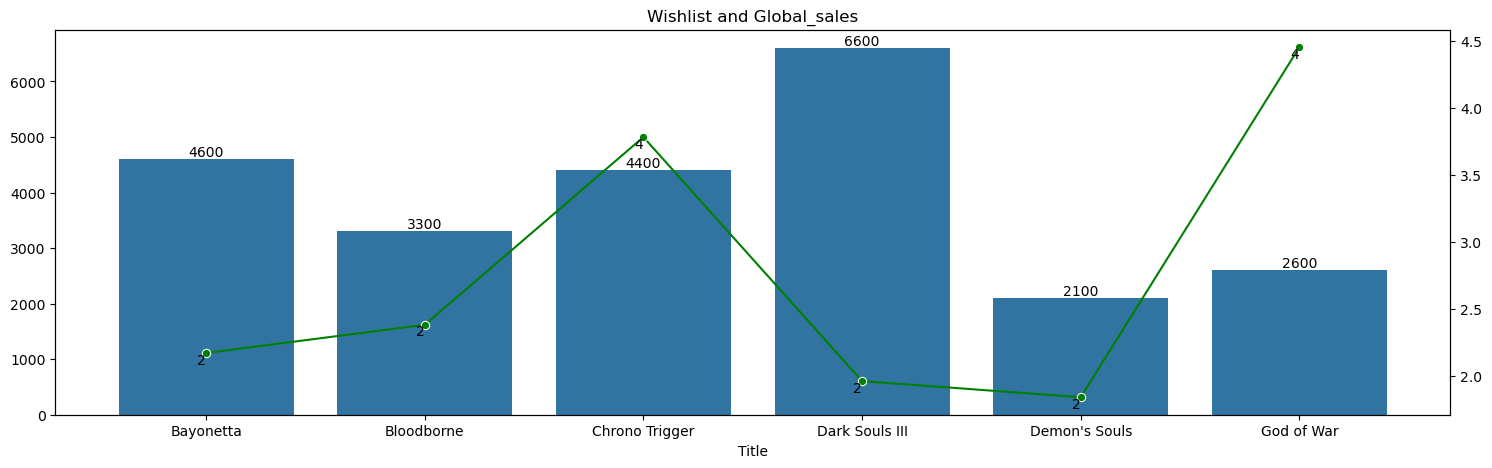

In [73]:
g = df4[['Title','Wishlist','Global_Sales']].drop_duplicates().sort_values(by = 'Wishlist',ascending = False).head(10)
gam_wish = g.groupby('Title')['Wishlist'].sum()
gam_sal = g.groupby('Title')['Global_Sales'].sum()

fig, ax1 = plt.subplots(figsize=(18, 5))

# Bar chart
sns.barplot(x=gam_wish.index, y=gam_wish.values, ax=ax1)

for p in ax1.patches:
    ax1.text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f"{int(p.get_height())}",
        ha="center",
        va="bottom"
    )

ax2 = ax1.twinx()
# Line chart (same axis)
sns.lineplot(x=gam_wish.index, y=gam_sal.values, ax=ax2, marker="o",color = 'green')
for x, y in zip(gam_wish.index, gam_sal.values):
    ax2.text(x,y,f"{y:.0f}",color="black",ha="right",va="top")

ax1.set_title("Wishlist and Global_sales")
ax1.set_xlabel("Title")
plt.show()

## 26. Which genres have the highest engagement but lowest sales?

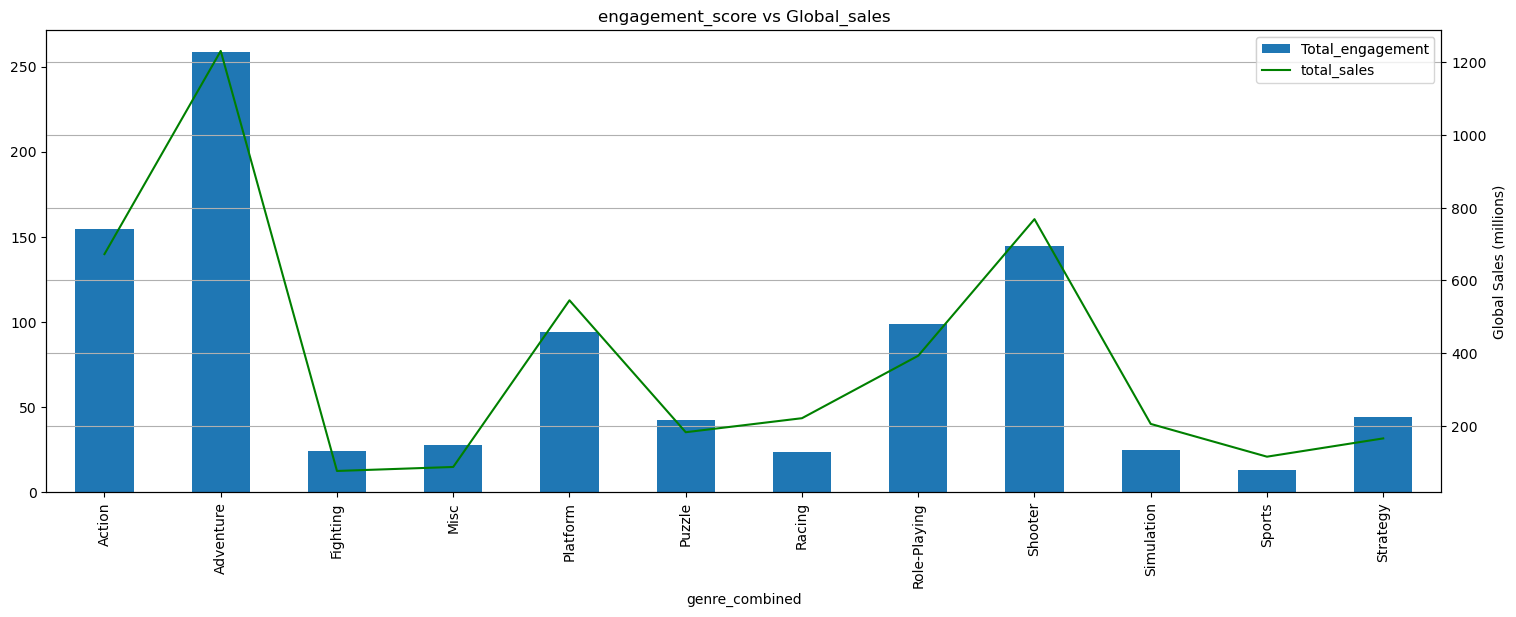

<Figure size 640x480 with 0 Axes>

In [74]:
x = df4[["genre_combined","Plays","Playing","Backlogs","Global_Sales"]]

# # Calculate engagement score 

x["engagement_score"] = (x["Playing"]  + 0.5*x["Plays"]) / (x["Backlogs"] + x["Plays"])

# # Aggregate sum engagement and total sales by genre
genre_summary = (x.groupby("genre_combined", as_index=False).agg(Total_engagement=("engagement_score", "sum"),
                                                                  total_sales=("Global_Sales", "sum")))


bar1 = genre_summary.plot(x = "genre_combined",y = "Total_engagement",  kind='bar',figsize=(18, 6))
ax2 = plt.twinx()
bar2 = genre_summary.plot(x = "genre_combined",y = "total_sales",  kind='line', color = 'green',ax=ax2)

# Get handles and labels from both axes
handles1, labels1 = bar1.get_legend_handles_labels()
handles2, labels2 = bar2.get_legend_handles_labels()

# Combine them
handles = handles1 + handles2
labels = labels1 + labels2

# Place combined legend outside the plot to avoid overlap
bar2.legend(handles, labels, loc='upper right')


plt.title('engagement_score vs Global_sales')
plt.xlabel('Genre')
ax1.set_label('Engagement score')
ax2.set_ylabel('Global Sales (millions)')

plt.grid(True)
plt.show()
plt.tight_layout()


## 27. Do highly listed games (wishlist/backlogs) correlate with better ratings?

In [75]:
cols = ["Wishlist", "Backlogs", "Rating"]

corr = df4[cols].corr(method="spearman")
corr

,Wishlist,Backlogs,Rating
Wishlist,1.000000,0.919449,0.587147
Backlogs,0.919449,1.000000,0.517579
Rating,0.587147,0.517579,1.000000


## 29. What are the top-performing combinations of Genre + Platform?

In [77]:
top_genre_platform = (
    df4
    .groupby(["genre_combined", "Platform"], as_index=False)
    .agg(total_sales=("Global_Sales", "sum"))
    .sort_values("total_sales", ascending=False)
)
top_genre_platform.head(10)

,genre_combined,Platform,total_sales
175,Shooter,X360,239.43
36,Adventure,PS3,227.07
168,Shooter,PS3,212.54
44,Adventure,X360,188.87
13,Action,PS3,147.16
35,Adventure,PS2,124.57
12,Action,PS2,110.82
21,Action,X360,103.28
190,Simulation,Wii,92.04
42,Adventure,Wii,89.31


## 30. What does a regional sales heatmap by genre reveal?

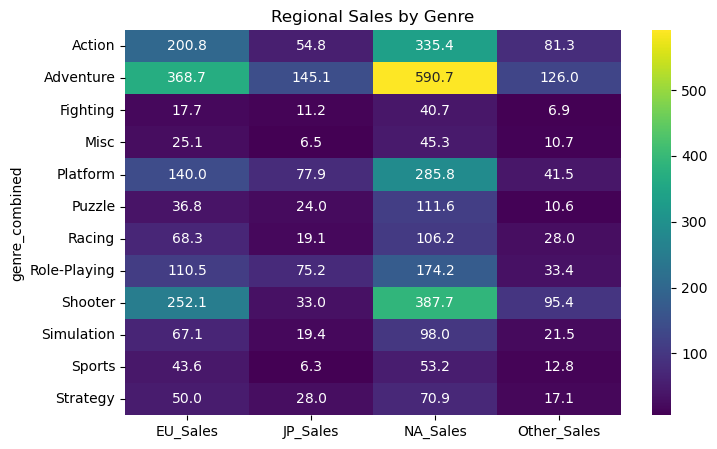

In [78]:
plt.figure(figsize = (8,5))
pivot = pd.pivot_table(df4,
    index="genre_combined",
    values=('NA_Sales', 'EU_Sales', 'JP_Sales','Other_Sales'),
    aggfunc="sum"
)

sns.heatmap(pivot, annot=True, fmt=".1f", cmap="viridis")
plt.title("Regional Sales by Genre")
plt.show()


In [79]:
df1.insert(0, 'games_id', range(1, len(df1) + 1))

In [80]:
df2.insert(0,'games_id',range(1,len(df2) + 1))


In [81]:
df1.to_csv('GAMES.csv',encoding = 'utf-8')
df2.to_csv('VGSALES.csv',encoding = 'utf-8')